 [Tanya's current file link](https://colab.research.google.com/drive/1KNRaiQ3coLgMNvgcZouDxcOwYFC19MP4?usp=sharing)

https://colab.research.google.com/drive/1fOgmB8u7GxpSx4jtJF7TUKAmyK56ibm2?usp=drive_link



# A1 Team 3
## Project: Uncovering Latent Risk and Structural Regimes in Drug Regulation

**Members:** Tanya Chhabra, Abhi Jindal, Daaksha B. Arun and Mahesh Wadhokar


## 1: Installing Dependencies

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

In [52]:
from google.colab import data_table
from google.colab import drive
# Enable the interactive table feature
data_table.enable_dataframe_formatter()
# Access Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2: Loading Dataset

In [53]:
primary_data = pd.read_csv('/content/drive/MyDrive/ML Project /updated Medicines_output_european_public_assessment_reports.csv', encoding='latin1')

primary_data.head()

,ï»¿Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,GONAL-f,"Anovulation; Reproductive Techniques, Assiste...",follitropin alfa,follitropin alfa,EMEA/H/C/000071,no,Authorised,G03GA05,no,...,NaN,NaN,21/07/2022,25.0,", \tAnovulation (including polycystic ovarian ...",NaN,NaN,43167,44721,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Taxotere,"Head and Neck Neoplasms; Carcinoma, Non-Small...",docetaxel,docetaxel,EMEA/H/C/000073,no,Authorised,L01CD02,no,...,NaN,35040,44389,49.0,Breast cancerTaxotere in combination with doxo...,NaN,NaN,43102,14/12/2021,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Betaferon,Multiple Sclerosis,interferon beta-1b,interferon beta-1b,EMEA/H/C/000081,no,Authorised,L03AB08,no,...,NaN,35040,44785,35.0,Betaferon is indicated for the treatment ofpat...,NaN,NaN,28/07/2017,45261,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,CellCept,Graft Rejection,mycophenolate mofetil,mycophenolate mofetil,EMEA/H/C/000082,no,Authorised,L04AA06,no,...,NaN,NaN,16/02/2022,37.0,CellCept is indicated in combination with cicl...,NaN,NaN,43351,44595,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Fareston,Breast Neoplasms,toremifene,toremifene,EMEA/H/C/000091,no,Authorised,L02BA02,no,...,NaN,17/10/1995,24/11/2021,24.0,First line hormone treatment of hormone-depend...,NaN,NaN,26/07/2018,44267,https://www.ema.europa.eu/en/medicines/human/E...


In [54]:
print(f"Primary Data Shape: {primary_data.shape}")

Primary Data Shape: (1988, 30)


In [55]:
print(primary_data.columns.tolist())

['ï»¿Category', 'Medicine name', 'Therapeutic area', 'International non-proprietary name (INN) / common name', 'Active substance', 'Product number', 'Patient safety', 'Authorisation status', 'ATC code', 'Additional monitoring', 'Generic', 'Biosimilar', 'Conditional approval', 'Exceptional circumstances', 'Accelerated assessment', 'Orphan medicine', 'Marketing authorisation date', 'Date of refusal of marketing authorisation', 'Marketing authorisation holder/company name', 'Human pharmacotherapeutic group', 'Vet pharmacotherapeutic group', 'Date of opinion', 'Decision date', 'Revision number', 'Condition / indication', 'Species', 'ATCvet code', 'First published', 'Revision date', 'URL']


In [56]:
# Removing the BOM prefix
primary_data.columns = primary_data.columns.str.replace('ï»¿', '').str.strip()
print(primary_data.columns.tolist())

['Category', 'Medicine name', 'Therapeutic area', 'International non-proprietary name (INN) / common name', 'Active substance', 'Product number', 'Patient safety', 'Authorisation status', 'ATC code', 'Additional monitoring', 'Generic', 'Biosimilar', 'Conditional approval', 'Exceptional circumstances', 'Accelerated assessment', 'Orphan medicine', 'Marketing authorisation date', 'Date of refusal of marketing authorisation', 'Marketing authorisation holder/company name', 'Human pharmacotherapeutic group', 'Vet pharmacotherapeutic group', 'Date of opinion', 'Decision date', 'Revision number', 'Condition / indication', 'Species', 'ATCvet code', 'First published', 'Revision date', 'URL']


In [57]:
# binary flags for processing
primary_data['is_failure'] = primary_data['Authorisation status'].isin(['Refused', 'Withdrawn']).astype(int)
primary_data['is_orphan'] = (primary_data['Orphan medicine'].str.lower() == 'yes').astype(int)

# 3: Creating Organizational Profiles

In [58]:
# global failure rate calculation for every active substance
api_risk_map = primary_data.groupby('Active substance')['is_failure'].mean().to_dict()
primary_data['substance_risk_score'] = primary_data['Active substance'].map(api_risk_map)

# data aggregation for Marketing Authorisation Holder (MAH) level
mah_profile = primary_data.groupby('Marketing authorisation holder/company name').agg({'Medicine name': 'count','Revision number': 'mean','is_orphan': 'mean',
    'substance_risk_score': 'mean','is_failure': 'mean'}).rename(columns={'Medicine name': 'Portfolio_Size', 'is_failure': 'Failure_Rate'})

# Filtering low-volume companies for statistical significance
mah_final = mah_profile[mah_profile['Portfolio_Size'] > 1].copy()

## 4: Explorartory Data Analysis (EDA)

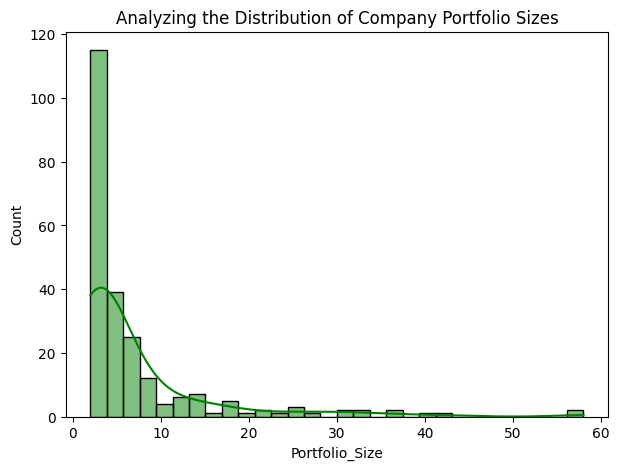

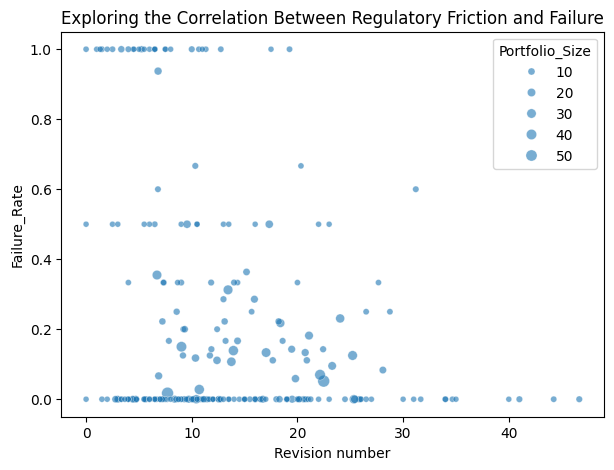

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# plotting distribution of portfolio size to identifying skewness
plt.figure(figsize=(7, 5))
sns.histplot(mah_final['Portfolio_Size'], bins=30, kde=True, color='green')
plt.title('Analyzing the Distribution of Company Portfolio Sizes')
plt.show()

# identifying relationship between revision counts and failure rates
plt.figure(figsize=(7, 5))
sns.scatterplot(data=mah_final, x='Revision number', y='Failure_Rate', size='Portfolio_Size', alpha=0.6)
plt.title('Exploring the Correlation Between Regulatory Friction and Failure')
plt.show()

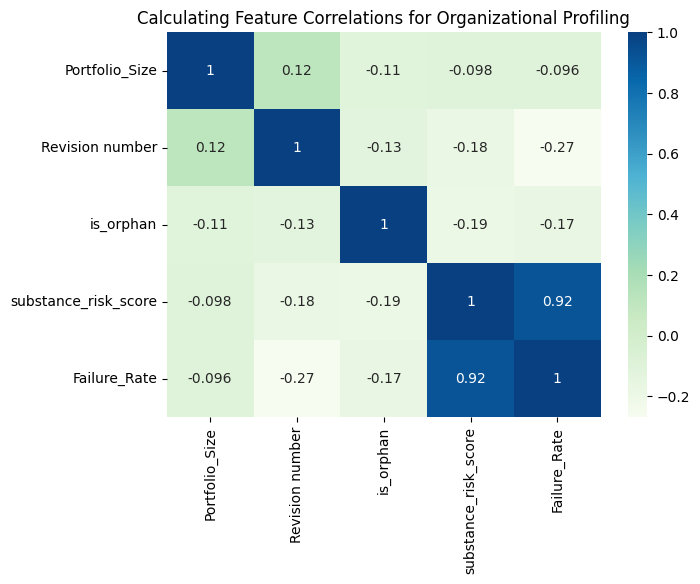

In [60]:
#feature correlations for identifying redundancy
plt.figure(figsize=(7, 5))
sns.heatmap(mah_final.corr(), annot=True, cmap='GnBu')
plt.title('Calculating Feature Correlations for Organizational Profiling')
plt.show()

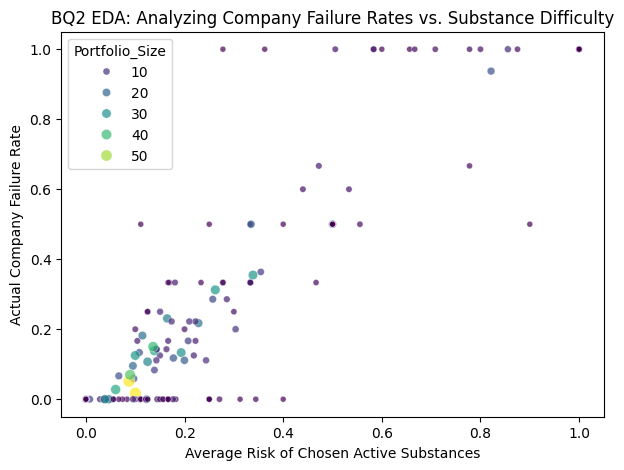

In [61]:
# relationship between substance difficulty and company failure rate
plt.figure(figsize=(7, 5))
sns.scatterplot(data=mah_final, x='substance_risk_score', y='Failure_Rate', size='Portfolio_Size', hue='Portfolio_Size', palette='viridis', alpha=0.7)
plt.title('BQ2 EDA: Analyzing Company Failure Rates vs. Substance Difficulty')
plt.xlabel('Average Risk of Chosen Active Substances')
plt.ylabel('Actual Company Failure Rate')
plt.show()

# 5: Implementing Hierarchical and K-Means Clustering

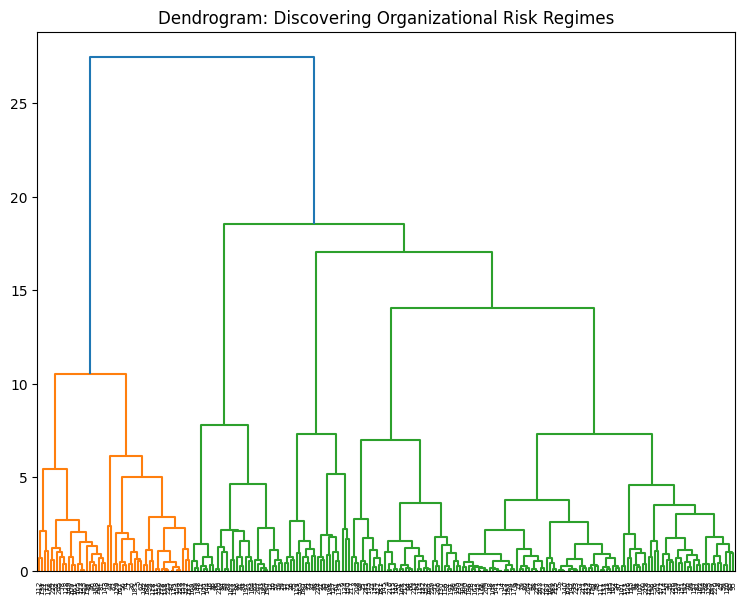

In [62]:
# StandardScaler for normalizing features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(mah_final)

# creating dendogram
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(9, 7))
dendrogram = sch.dendrogram(sch.linkage(scaled_features, method='ward'))
plt.title('Dendrogram: Discovering Organizational Risk Regimes')
plt.show()

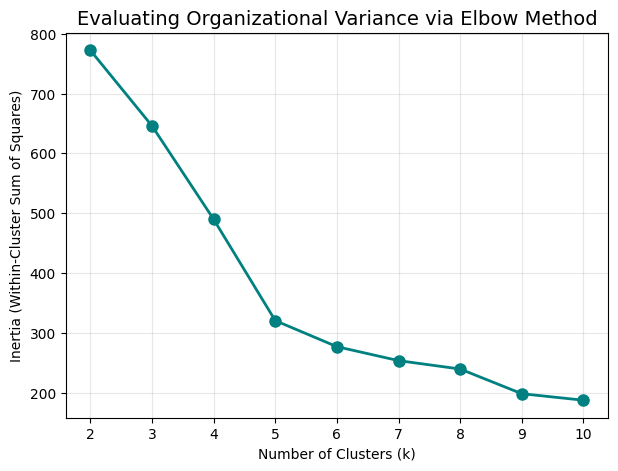

In [63]:
from sklearn.cluster import KMeans

# initializing for inertia storage
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(scaled_features)
    inertia.append(km.inertia_)

# Elbow curve for identifying the structural "knee"
plt.figure(figsize=(7, 5))
plt.plot(k_range, inertia, marker='o', color='#008080', linewidth=2, markersize=8)

# highlighting the optimal cluster point
plt.title('Evaluating Organizational Variance via Elbow Method', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True, alpha=0.3)
plt.show()

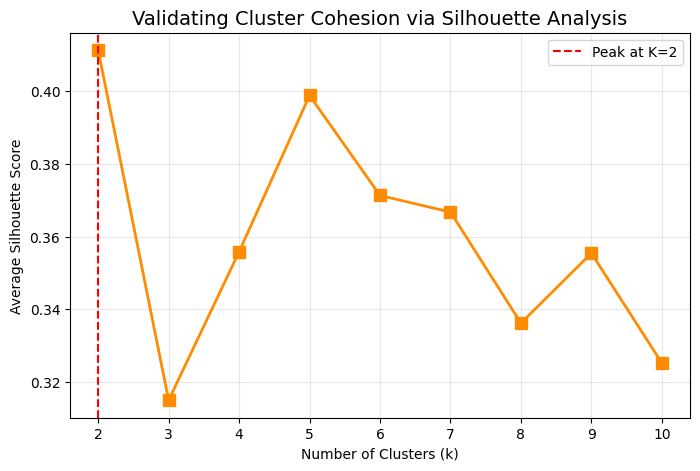

In [64]:
# initializing silhouette score storage
silhouette_avgs = []

# iterating through K-values for measuring cluster separation quality
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_avgs.append(score)

#Silhouette scores visualization
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_avgs, marker='s', color='#FF8C00', linewidth=2, markersize=8)

# Identifying the maximum score to justifying the final K choice
max_score_k = k_range[silhouette_avgs.index(max(silhouette_avgs))]
plt.axvline(max_score_k, color='red', linestyle='--', label=f'Peak at K={max_score_k}')

plt.title('Validating Cluster Cohesion via Silhouette Analysis', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [65]:
# applying the final K-Means model with your discovered K=5
km_final = KMeans(n_clusters=5, random_state=42, n_init='auto')
mah_final['Cluster_ID'] = km_final.fit_predict(scaled_features)

# averaging features to defining the 5 organizational archetypes
cluster_profiles = mah_final.groupby('Cluster_ID').mean()

print("Defining the 5 Latent Structural Regimes:")
display(cluster_profiles)

Defining the 5 Latent Structural Regimes:


,Portfolio_Size,Revision number,is_orphan,substance_risk_score,Failure_Rate
Cluster_ID,,,,,
0,5.574468,25.727997,0.031900,0.120128,0.073170
1,5.287129,9.393783,0.031739,0.100193,0.079691
2,3.731707,8.329980,0.016260,0.730113,0.838313
3,33.411765,16.748619,0.037961,0.136391,0.130202
4,3.230769,10.445604,0.706777,0.050519,0.049451


In [66]:
!pip install psynlig

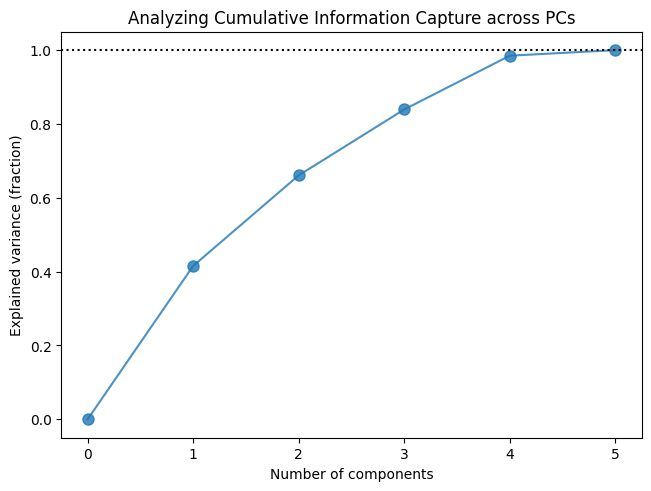

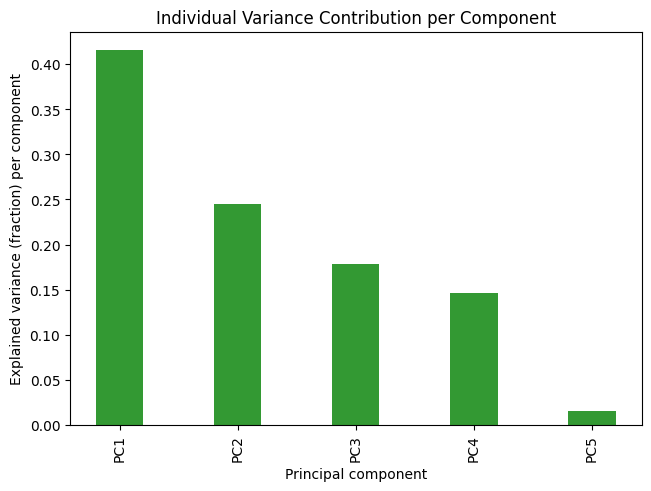

In [67]:
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

from psynlig import (pca_explained_variance,pca_explained_variance_bar,pca_2d_loadings)

# Initializing and fitting PCA
pca = PCA()
pca.fit(scaled_features)

# Plotting the Cumulative Explained Variance - Scree Plot
_, ax1 = pca_explained_variance(pca, marker='o', markersize=8, alpha=0.8)
ax1.set_title('Analyzing Cumulative Information Capture across PCs')
plt.show()

# Plotting the Individual Variance Bar Chart
pca_explained_variance_bar(pca, width=0.4, alpha=0.8, color='green',)
plt.title('Individual Variance Contribution per Component')
plt.show()

In [68]:
from sklearn.cluster import KMeans

# number of clusters (based on finding of K=5)
k_optimal = 5

# running the final K-Means model
km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
cluster_labels = km_final.fit_predict(scaled_features)

# adding the labels to dataframe
mah_final['Cluster_ID'] = cluster_labels
print("Cluster labels successfully assigned!")
print(mah_final['Cluster_ID'].value_counts())

Cluster labels successfully assigned!
Cluster_ID
1    101
0     47
2     41
4     26
3     17
Name: count, dtype: int64


In [69]:
import plotly.express as px

# creating a 3D PCA projection
pca_3d = PCA(n_components=3)
components = pca_3d.fit_transform(scaled_features)

# formatting the data for Plotly
total_var = pca_3d.explained_variance_ratio_.sum() * 100
labels = {str(i): f"PC {i+1}" for i in range(3)}

fig = px.scatter_3d(components, x=0, y=1, z=2, color=mah_final['Cluster_ID'].astype(str),title=f'Total Explained Variance: {total_var:.2f}%', labels=labels)
fig.update_layout(template="plotly_white",scene=dict(
        xaxis=dict(backgroundcolor="rgb(230, 230,230)", gridcolor="white", showbackground=True),
        yaxis=dict(backgroundcolor="rgb(230, 230,230)", gridcolor="white", showbackground=True),
        zaxis=dict(backgroundcolor="rgb(230, 230,230)", gridcolor="white", showbackground=True),
    ),
    margin=dict(l=0, r=0, b=0, t=40))
fig.show()